In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
%matplotlib inline

In [28]:
df = pd.read_csv('../data/csvs/examenes.csv')
df = df.sample(n = 200, replace = False)

In [29]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
16115,16116,19,female,ba,6.30,53.8,yes,7.6,poor,coaching,medium,moderate,75.3
13502,13503,20,female,diploma,5.64,97.7,no,4.1,average,self-study,low,easy,70.4
4129,4130,20,male,bca,5.01,44.5,yes,5.3,good,group study,low,moderate,62.5
10288,10289,19,female,b.com,0.52,97.9,yes,8.2,poor,mixed,high,easy,55.2
11482,11483,17,other,bca,4.02,78.1,yes,4.1,average,online videos,medium,moderate,52.7


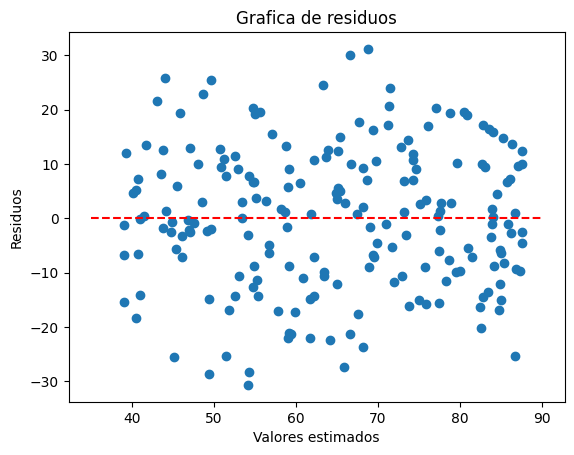

In [56]:
X = np.array(df[["study_hours"]])
y = np.array(df["exam_score"])

X = sm.add_constant(X)

model = sm.OLS(y, X)

result = model.fit()

result.summary()


x_falsa = np.linspace(0,9, 2)
y_estimada = result.predict(x_falsa)


y_estimada_real = result.predict(X)
residuos = y - y_estimada_real
plt.show()

plt.scatter(y_estimada_real, residuos)
plt.title("Grafica de residuos")
plt.xlabel("Valores estimados")
plt.ylabel("Residuos")
plt.hlines(0,35,90, linestyles="--", color = "r")
plt.show()

In [59]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     244.5
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           2.03e-36
Time:                        19:45:17   Log-Likelihood:                -796.66
No. Observations:                 200   AIC:                             1597.
Df Residuals:                     198   BIC:                             1604.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.5281      1.920     20.062      0.000      34.741      42.315
x1             6.1948      0.396     15.636      0.000       5.413       6.976
==============================================================================
Omnibus:                        4.274   Durbin-Watson:                   1.950
Prob(Omnibus):                  0.118   Jarque-Bera (JB):                2.736
Skew:                          -0.074   Prob(JB):                        0.255
Kurtosis:                       2.447   Cond. No.                         10.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [57]:
df

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
16115,16116,19,female,ba,6.30,53.8,yes,7.6,poor,coaching,medium,moderate,75.3
13502,13503,20,female,diploma,5.64,97.7,no,4.1,average,self-study,low,easy,70.4
4129,4130,20,male,bca,5.01,44.5,yes,5.3,good,group study,low,moderate,62.5
10288,10289,19,female,b.com,0.52,97.9,yes,8.2,poor,mixed,high,easy,55.2
11482,11483,17,other,bca,4.02,78.1,yes,4.1,average,online videos,medium,moderate,52.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10426,10427,23,male,bca,7.87,71.9,yes,5.7,average,self-study,low,moderate,77.5
17012,17013,19,other,bca,5.76,42.3,no,4.8,good,mixed,high,moderate,86.1
14106,14107,24,male,b.com,5.77,48.4,yes,9.5,average,coaching,high,moderate,85.0
13177,13178,23,other,b.tech,4.02,68.6,yes,7.4,average,online videos,low,hard,53.5


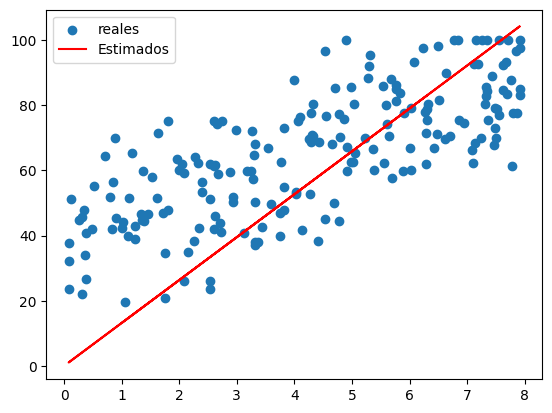

In [31]:
X = np.array(df[["study_hours"]])
x = X
y_pred = result.predict(x)

plt.scatter(X, y, label = "reales")
plt.plot(x,y_pred, color = "r", label = "Estimados")
plt.legend()

residuo = y_real - y_estimada

In [32]:
print(X[0], y[0], result.predict(X[0]))

[6.3] 75.3 [82.9343975]


Text(0, 0.5, 'Residuos')

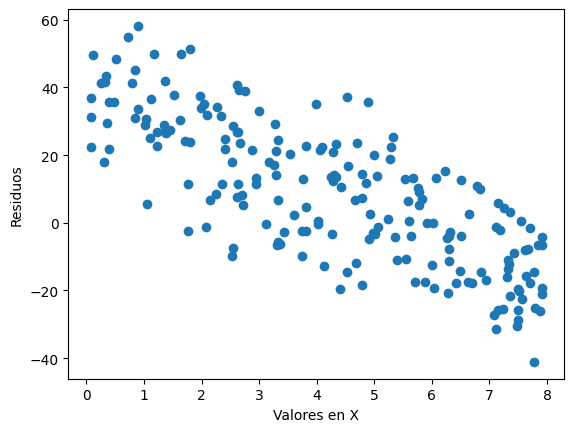

In [33]:
residuos = []
X = list(X)
y = list(y)
for i in range(len(X)):
    residuos.append(y[i] - result.predict(X[i]))
    
plt.scatter(X, residuos)
plt.xlabel("Valores en X")
plt.ylabel("Residuos")

Rompe los supuestos de la regresion lineal